/Users/sakshiparikh/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Starting CIFAR-10 CNN Experiments...
This will take some time depending on your hardware (GPU recommended)
--------------------------------------------------------------------------------
Loading CIFAR-10 dataset...
Training set: (45000, 32, 32, 3)
Validation set: (5000, 32, 32, 3)
Test set: (10000, 32, 32, 3)

Experiment 1/8: Baseline
Model architecture: 814,122 parameters
Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 31s 84ms/step - accuracy: 0.3122 - loss: 1.8477 - val_accuracy: 0.5570 - val_loss: 1.2230 - learning_rate: 0.0010
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 31s 89ms/step - accuracy: 0.5737 - loss: 1.1871 - val_accuracy: 0.6556 - val_loss: 0.9925 - learning_rate: 0.0010
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.6793 - loss: 0.9149 - val_accuracy: 0.7056 - val_loss: 0.8488 - learning_rate: 0.0010
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 40s 114ms/step - accuracy: 0.7360 - loss: 0.7522 - val_accuracy: 0.7278 - val_loss: 0.7937 - learning_rate: 0.0010
Epoch 

/var/folders/ml/6hz3gr913wb87l0j9zc_6wl40000gn/T/ipykernel_21423/3446672350.py:409: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(depth_results.keys(), rotation=45, ha='right')


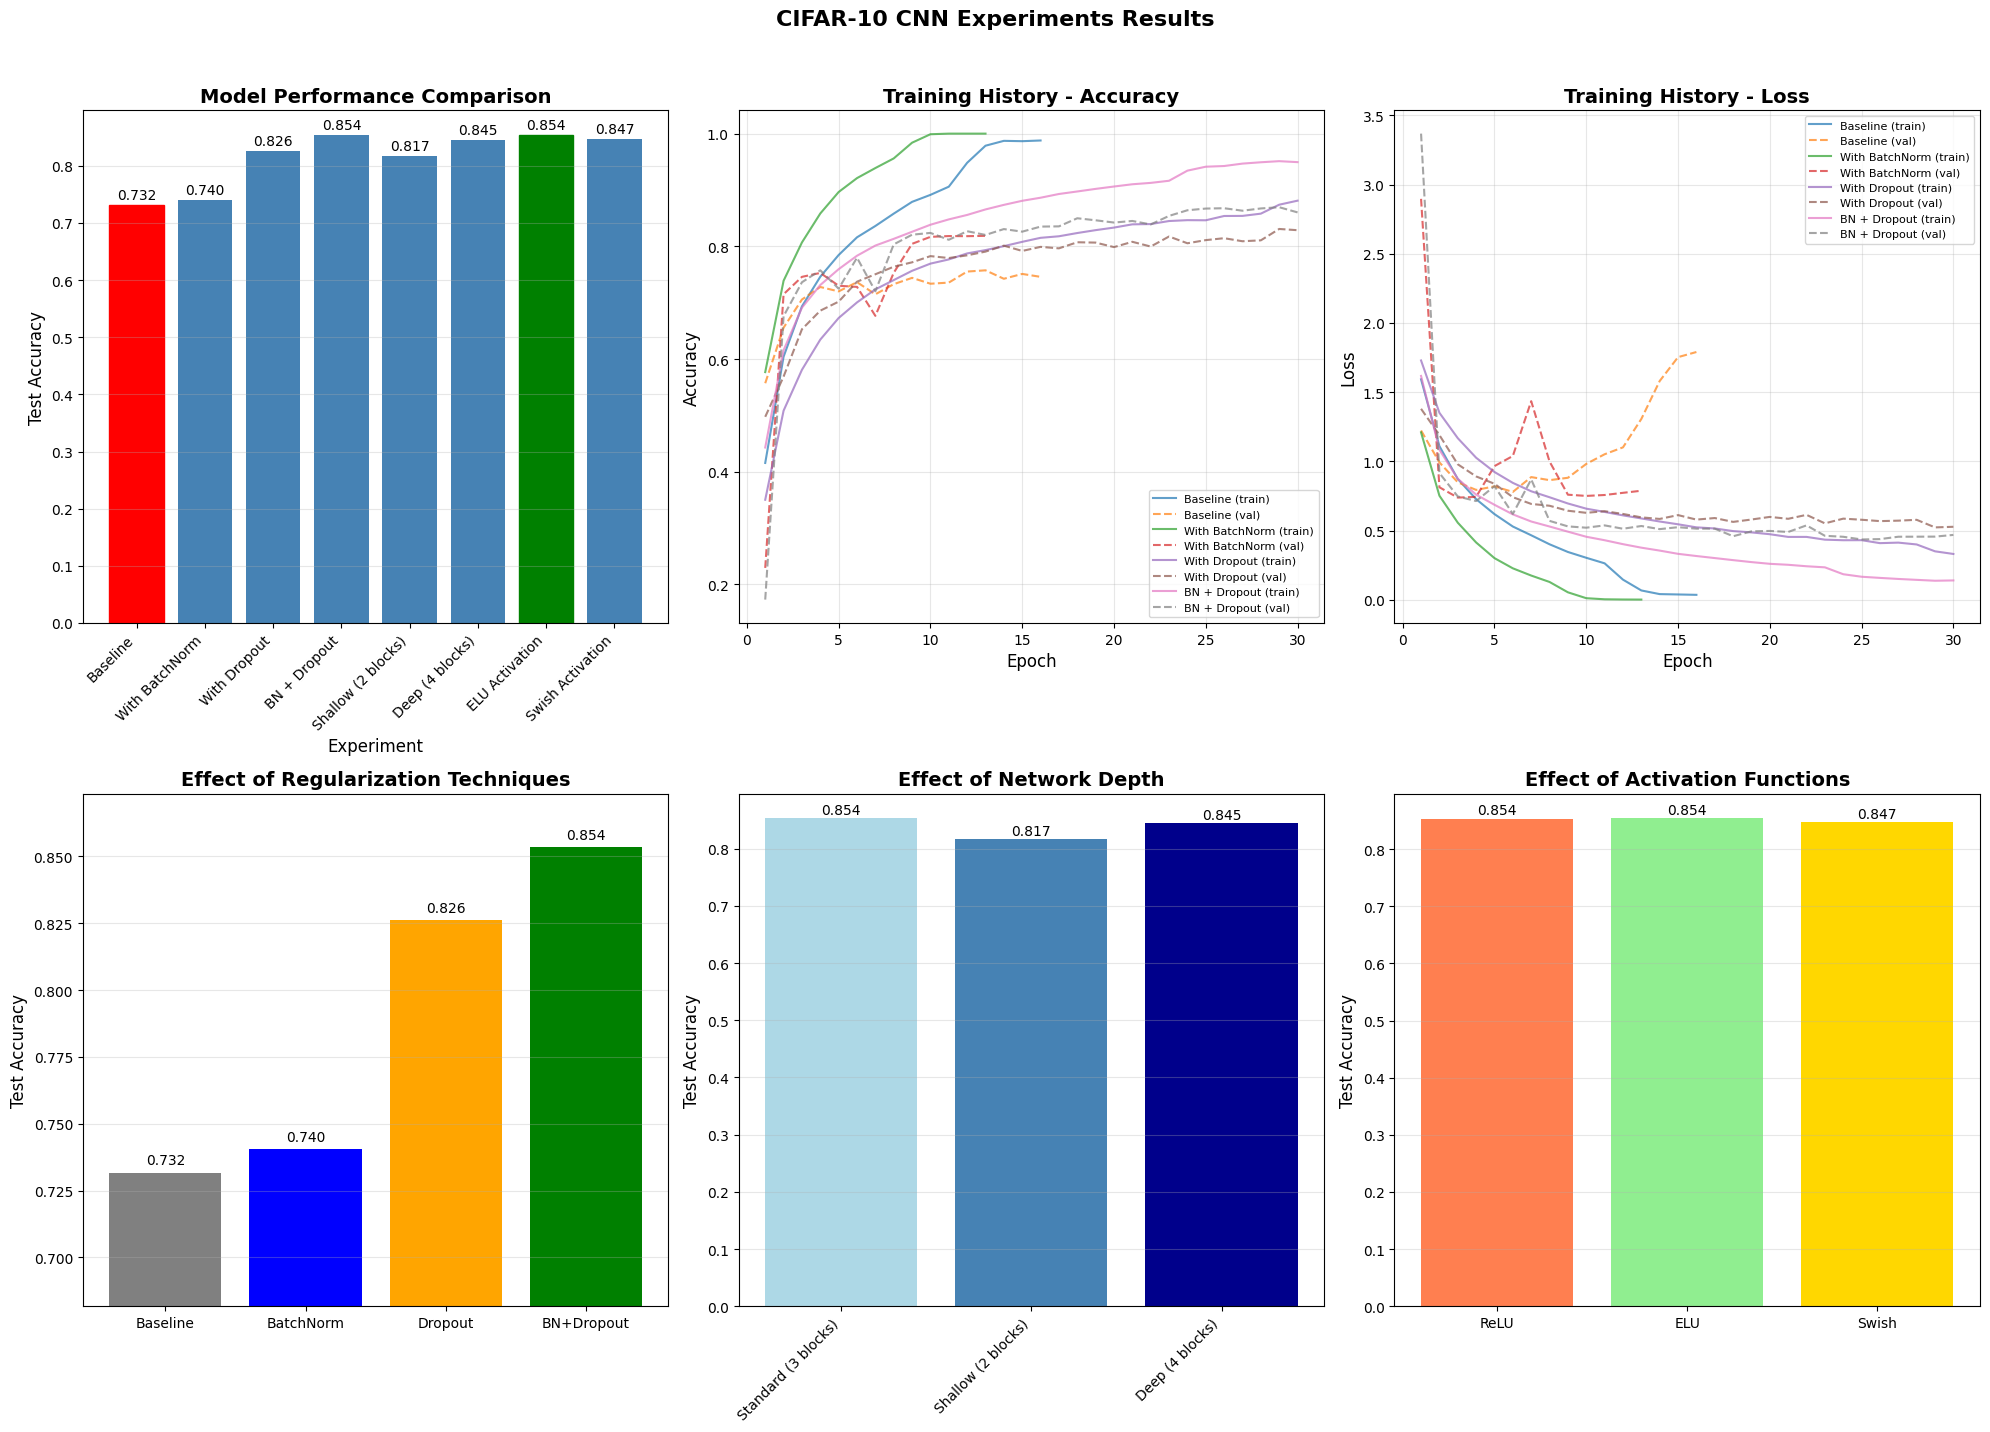


EXPERIMENT SUMMARY

📊 PERFORMANCE OVERVIEW:
Best Model: ELU Activation - Accuracy: 0.8545
Worst Model: Baseline - Accuracy: 0.7317
Improvement: 12.28%

📈 DETAILED RESULTS:
--------------------------------------------------------------------------------
Experiment                  Accuracy       Loss     Improvement
--------------------------------------------------------------------------------
Baseline                      0.7317     0.8009 +          0.00%
With BatchNorm                0.7404     0.7664 +          0.87%
With Dropout                  0.8261     0.5655 +          9.44%
BN + Dropout                  0.8535     0.5041 +         12.18%
Shallow (2 blocks)            0.8174     0.6057 +          8.57%
Deep (4 blocks)               0.8454     0.5827 +         11.37%
ELU Activation                0.8545     0.5185 +         12.28%
Swish Activation              0.8468     0.5182 +         11.51%

🔍 KEY FINDINGS:
----------------------------------------------------------------

In [1]:
"""
PART A: CNN FOR CIFAR-10 CLASSIFICATION
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
import json
import time

# Deep Learning imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

class CNNExperiment:
    """
    Flexible CNN architecture for CIFAR-10 experiments
    """
    
    def __init__(self, config: Dict):
        """
        Initialize CNN with configuration
        
        Args:
            config: Dictionary with model configuration
                - use_batch_norm: bool
                - use_dropout: bool
                - dropout_rate: float
                - num_conv_blocks: int
                - activation: str ('relu', 'elu', 'swish', 'tanh')
                - filters: list of filter counts
        """
        self.config = config
        self.model = None
        self.history = None
        
    def build_model(self, input_shape=(32, 32, 3), num_classes=10):
        """Build CNN model based on configuration"""
        
        model = models.Sequential()
        
        # Input layer
        model.add(layers.Input(shape=input_shape))
        
        # Add convolutional blocks
        filters = self.config.get('filters', [32, 64, 128])
        num_blocks = self.config.get('num_conv_blocks', 3)
        activation = self.config.get('activation', 'relu')
        
        for i in range(min(num_blocks, len(filters))):
            # Conv layer
            model.add(layers.Conv2D(
                filters[i], 
                kernel_size=(3, 3),
                padding='same',
                activation=activation
            ))
            
            # Optional: Batch Normalization
            if self.config.get('use_batch_norm', False):
                model.add(layers.BatchNormalization())
            
            # Second conv in block
            model.add(layers.Conv2D(
                filters[i],
                kernel_size=(3, 3),
                padding='same',
                activation=activation
            ))
            
            # Optional: Batch Normalization
            if self.config.get('use_batch_norm', False):
                model.add(layers.BatchNormalization())
            
            # Pooling layer
            model.add(layers.MaxPooling2D(pool_size=(2, 2)))
            
            # Optional: Dropout
            if self.config.get('use_dropout', False):
                model.add(layers.Dropout(self.config.get('dropout_rate', 0.25)))
        
        # Flatten and Dense layers
        model.add(layers.Flatten())
        model.add(layers.Dense(256, activation=activation))
        
        if self.config.get('use_batch_norm', False):
            model.add(layers.BatchNormalization())
            
        if self.config.get('use_dropout', False):
            model.add(layers.Dropout(self.config.get('dropout_rate', 0.5)))
        
        # Output layer
        model.add(layers.Dense(num_classes, activation='softmax'))
        
        self.model = model
        return model
    
    def compile_model(self, learning_rate=0.001):
        """Compile the model"""
        self.model.compile(
            optimizer=optimizers.Adam(learning_rate=learning_rate),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    
    def train(self, X_train, y_train, X_val, y_val, epochs=50, batch_size=128):
        """Train the model"""
        
        # Callbacks
        early_stop = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
        
        reduce_lr = callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=0.00001
        )
        
        # Train
        self.history = self.model.fit(
            X_train, y_train,
            batch_size=batch_size,
            epochs=epochs,
            validation_data=(X_val, y_val),
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )
        
        return self.history
    
    def evaluate(self, X_test, y_test):
        """Evaluate model performance"""
        loss, accuracy = self.model.evaluate(X_test, y_test, verbose=0)
        
        # Get predictions
        y_pred = self.model.predict(X_test)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true_classes = np.argmax(y_test, axis=1)
        
        return {
            'loss': loss,
            'accuracy': accuracy,
            'y_true': y_true_classes,
            'y_pred': y_pred_classes,
            'config': self.config
        }


def load_and_preprocess_cifar10():
    """Load and preprocess CIFAR-10 dataset"""
    
    print("Loading CIFAR-10 dataset...")
    
    # Load data
    (X_train, y_train), (X_test, y_test) = cifar10.load_data()
    
    # Normalize pixel values
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0
    
    # Convert labels to categorical
    y_train = to_categorical(y_train, 10)
    y_test = to_categorical(y_test, 10)
    
    # Split training data for validation
    val_split = 0.1
    val_size = int(len(X_train) * val_split)
    
    X_val = X_train[:val_size]
    y_val = y_train[:val_size]
    X_train = X_train[val_size:]
    y_train = y_train[val_size:]
    
    print(f"Training set: {X_train.shape}")
    print(f"Validation set: {X_val.shape}")
    print(f"Test set: {X_test.shape}")
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


def run_experiments():
    """Run multiple CNN experiments with different configurations"""
    
    # Load data once
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = load_and_preprocess_cifar10()
    
    # Define experiment configurations
    experiments = [
        # Baseline
        {
            'name': 'Baseline',
            'use_batch_norm': False,
            'use_dropout': False,
            'num_conv_blocks': 3,
            'activation': 'relu',
            'filters': [32, 64, 128]
        },
        # With Batch Normalization
        {
            'name': 'With BatchNorm',
            'use_batch_norm': True,
            'use_dropout': False,
            'num_conv_blocks': 3,
            'activation': 'relu',
            'filters': [32, 64, 128]
        },
        # With Dropout
        {
            'name': 'With Dropout',
            'use_batch_norm': False,
            'use_dropout': True,
            'dropout_rate': 0.3,
            'num_conv_blocks': 3,
            'activation': 'relu',
            'filters': [32, 64, 128]
        },
        # With Both BN and Dropout
        {
            'name': 'BN + Dropout',
            'use_batch_norm': True,
            'use_dropout': True,
            'dropout_rate': 0.3,
            'num_conv_blocks': 3,
            'activation': 'relu',
            'filters': [32, 64, 128]
        },
        # Shallow Network (2 conv blocks)
        {
            'name': 'Shallow (2 blocks)',
            'use_batch_norm': True,
            'use_dropout': True,
            'dropout_rate': 0.3,
            'num_conv_blocks': 2,
            'activation': 'relu',
            'filters': [32, 64]
        },
        # Deep Network (4 conv blocks)
        {
            'name': 'Deep (4 blocks)',
            'use_batch_norm': True,
            'use_dropout': True,
            'dropout_rate': 0.3,
            'num_conv_blocks': 4,
            'activation': 'relu',
            'filters': [32, 64, 128, 256]
        },
        # Different Activation - ELU
        {
            'name': 'ELU Activation',
            'use_batch_norm': True,
            'use_dropout': True,
            'dropout_rate': 0.3,
            'num_conv_blocks': 3,
            'activation': 'elu',
            'filters': [32, 64, 128]
        },
        # Different Activation - Swish
        {
            'name': 'Swish Activation',
            'use_batch_norm': True,
            'use_dropout': True,
            'dropout_rate': 0.3,
            'num_conv_blocks': 3,
            'activation': 'swish',
            'filters': [32, 64, 128]
        }
    ]
    
    results = []
    
    for i, config in enumerate(experiments):
        print(f"\n{'='*60}")
        print(f"Experiment {i+1}/{len(experiments)}: {config['name']}")
        print(f"{'='*60}")
        
        # Create and train model
        experiment = CNNExperiment(config)
        experiment.build_model()
        experiment.compile_model()
        
        print(f"Model architecture: {experiment.model.count_params():,} parameters")
        
        # Train with fewer epochs for demonstration (increase for better results)
        history = experiment.train(
            X_train, y_train, 
            X_val, y_val,
            epochs=30,  # Increase to 50-100 for better results
            batch_size=128
        )
        
        # Evaluate
        eval_results = experiment.evaluate(X_test, y_test)
        eval_results['name'] = config['name']
        eval_results['history'] = history.history
        
        results.append(eval_results)
        
        print(f"\nTest Accuracy: {eval_results['accuracy']:.4f}")
        print(f"Test Loss: {eval_results['loss']:.4f}")
        
    return results


def visualize_results(results):
    """Create comprehensive visualizations for experiment results"""
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 14))
    
    # 1. Accuracy Comparison Bar Chart
    ax1 = plt.subplot(2, 3, 1)
    names = [r['name'] for r in results]
    accuracies = [r['accuracy'] for r in results]
    
    bars = ax1.bar(range(len(names)), accuracies, color='steelblue')
    ax1.set_xlabel('Experiment', fontsize=12)
    ax1.set_ylabel('Test Accuracy', fontsize=12)
    ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
    ax1.set_xticks(range(len(names)))
    ax1.set_xticklabels(names, rotation=45, ha='right')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Highlight best and worst
    best_idx = np.argmax(accuracies)
    worst_idx = np.argmin(accuracies)
    bars[best_idx].set_color('green')
    bars[worst_idx].set_color('red')
    
    # Add value labels on bars
    for i, (bar, acc) in enumerate(zip(bars, accuracies)):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{acc:.3f}',
                ha='center', va='bottom', fontsize=10)
    
    # 2. Training History - Accuracy
    ax2 = plt.subplot(2, 3, 2)
    for result in results[:4]:  # Show first 4 to avoid clutter
        epochs = range(1, len(result['history']['accuracy']) + 1)
        ax2.plot(epochs, result['history']['accuracy'], label=f"{result['name']} (train)", alpha=0.7)
        ax2.plot(epochs, result['history']['val_accuracy'], '--', label=f"{result['name']} (val)", alpha=0.7)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Training History - Accuracy', fontsize=14, fontweight='bold')
    ax2.legend(loc='lower right', fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # 3. Training History - Loss
    ax3 = plt.subplot(2, 3, 3)
    for result in results[:4]:
        epochs = range(1, len(result['history']['loss']) + 1)
        ax3.plot(epochs, result['history']['loss'], label=f"{result['name']} (train)", alpha=0.7)
        ax3.plot(epochs, result['history']['val_loss'], '--', label=f"{result['name']} (val)", alpha=0.7)
    ax3.set_xlabel('Epoch', fontsize=12)
    ax3.set_ylabel('Loss', fontsize=12)
    ax3.set_title('Training History - Loss', fontsize=14, fontweight='bold')
    ax3.legend(loc='upper right', fontsize=8)
    ax3.grid(True, alpha=0.3)
    
    # 4. Effect of Batch Norm and Dropout
    ax4 = plt.subplot(2, 3, 4)
    bn_dropout_results = {
        'Baseline': next(r['accuracy'] for r in results if r['name'] == 'Baseline'),
        'BatchNorm': next(r['accuracy'] for r in results if r['name'] == 'With BatchNorm'),
        'Dropout': next(r['accuracy'] for r in results if r['name'] == 'With Dropout'),
        'BN+Dropout': next(r['accuracy'] for r in results if r['name'] == 'BN + Dropout')
    }
    
    colors = ['gray', 'blue', 'orange', 'green']
    bars = ax4.bar(bn_dropout_results.keys(), bn_dropout_results.values(), color=colors)
    ax4.set_ylabel('Test Accuracy', fontsize=12)
    ax4.set_title('Effect of Regularization Techniques', fontsize=14, fontweight='bold')
    ax4.set_ylim([min(bn_dropout_results.values()) - 0.05, max(bn_dropout_results.values()) + 0.02])
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, val in zip(bars, bn_dropout_results.values()):
        ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    
    # 5. Effect of Network Depth
    ax5 = plt.subplot(2, 3, 5)
    depth_results = {}
    for r in results:
        if 'blocks' in r['name']:
            depth_results[r['name']] = r['accuracy']
        elif r['name'] == 'BN + Dropout':
            depth_results['Standard (3 blocks)'] = r['accuracy']
    
    if depth_results:
        colors = ['lightblue', 'steelblue', 'darkblue']
        bars = ax5.bar(depth_results.keys(), depth_results.values(), color=colors[:len(depth_results)])
        ax5.set_ylabel('Test Accuracy', fontsize=12)
        ax5.set_title('Effect of Network Depth', fontsize=14, fontweight='bold')
        ax5.set_xticklabels(depth_results.keys(), rotation=45, ha='right')
        ax5.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bar, val in zip(bars, depth_results.values()):
            ax5.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    
    # 6. Effect of Activation Functions
    ax6 = plt.subplot(2, 3, 6)
    activation_results = {}
    for r in results:
        if 'Activation' in r['name']:
            activation_results[r['name'].replace(' Activation', '')] = r['accuracy']
        elif r['name'] == 'BN + Dropout':
            activation_results['ReLU'] = r['accuracy']
    
    if activation_results:
        colors = ['coral', 'lightgreen', 'gold']
        bars = ax6.bar(activation_results.keys(), activation_results.values(), color=colors[:len(activation_results)])
        ax6.set_ylabel('Test Accuracy', fontsize=12)
        ax6.set_title('Effect of Activation Functions', fontsize=14, fontweight='bold')
        ax6.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bar, val in zip(bars, activation_results.values()):
            ax6.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.suptitle('CIFAR-10 CNN Experiments Results', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig


def print_summary(results):
    """Print a comprehensive summary of results"""
    
    print("\n" + "="*80)
    print("EXPERIMENT SUMMARY")
    print("="*80)
    
    # Find best performing model
    best_model = max(results, key=lambda x: x['accuracy'])
    worst_model = min(results, key=lambda x: x['accuracy'])
    
    print(f"\n📊 PERFORMANCE OVERVIEW:")
    print(f"Best Model: {best_model['name']} - Accuracy: {best_model['accuracy']:.4f}")
    print(f"Worst Model: {worst_model['name']} - Accuracy: {worst_model['accuracy']:.4f}")
    print(f"Improvement: {(best_model['accuracy'] - worst_model['accuracy'])*100:.2f}%")
    
    print(f"\n📈 DETAILED RESULTS:")
    print("-"*80)
    print(f"{'Experiment':<25} {'Accuracy':>10} {'Loss':>10} {'Improvement':>15}")
    print("-"*80)
    
    baseline_acc = results[0]['accuracy']
    for result in results:
        improvement = (result['accuracy'] - baseline_acc) * 100
        sign = '+' if improvement >= 0 else ''
        print(f"{result['name']:<25} {result['accuracy']:>10.4f} {result['loss']:>10.4f} {sign}{improvement:>14.2f}%")
    
    print("\n🔍 KEY FINDINGS:")
    print("-"*80)
    
    # Analyze regularization effect
    baseline = next(r for r in results if r['name'] == 'Baseline')
    bn_only = next(r for r in results if r['name'] == 'With BatchNorm')
    dropout_only = next(r for r in results if r['name'] == 'With Dropout')
    both = next(r for r in results if r['name'] == 'BN + Dropout')
    
    print(f"1. Regularization Impact:")
    print(f"   - Batch Normalization: +{(bn_only['accuracy']-baseline['accuracy'])*100:.2f}% improvement")
    print(f"   - Dropout: +{(dropout_only['accuracy']-baseline['accuracy'])*100:.2f}% improvement")
    print(f"   - Combined: +{(both['accuracy']-baseline['accuracy'])*100:.2f}% improvement")
    
    # Analyze depth effect
    shallow = next((r for r in results if 'Shallow' in r['name']), None)
    deep = next((r for r in results if 'Deep' in r['name']), None)
    
    if shallow and deep:
        print(f"\n2. Network Depth Analysis:")
        print(f"   - Shallow (2 blocks): {shallow['accuracy']:.4f}")
        print(f"   - Standard (3 blocks): {both['accuracy']:.4f}")
        print(f"   - Deep (4 blocks): {deep['accuracy']:.4f}")
    
    # Analyze activation functions
    print(f"\n3. Activation Function Comparison:")
    for r in results:
        if 'Activation' in r['name'] or r['name'] == 'BN + Dropout':
            act_name = r['name'].replace(' Activation', '') if 'Activation' in r['name'] else 'ReLU'
            print(f"   - {act_name}: {r['accuracy']:.4f}")


# Run all experiments
print("Starting CIFAR-10 CNN Experiments...")
print("This will take some time depending on your hardware (GPU recommended)")
print("-"*80)

# Execute experiments
results = run_experiments()

# Visualize results
print("\nGenerating visualizations...")
fig = visualize_results(results)

# Print summary
print_summary(results)

# Save results to JSON
results_for_json = []
for r in results:
    result_dict = {
        'name': r['name'],
        'accuracy': float(r['accuracy']),
        'loss': float(r['loss']),
        'final_train_acc': float(r['history']['accuracy'][-1]),
        'final_val_acc': float(r['history']['val_accuracy'][-1])
    }
    results_for_json.append(result_dict)

with open('cifar10_cnn_results.json', 'w') as f:
    json.dump(results_for_json, f, indent=2)

print("\n✅ Results saved to 'cifar10_cnn_results.json'")
print("="*80)